<a href="https://colab.research.google.com/github/emeskuhmar-ux/HomeWorks/blob/main/Ass01_cantilever_load_cases_Sol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cantilever Beam Load Cases

This notebook is the first homework extension after Session 01.

Use the cantilever beam under a tip load as your reference case and extend it to additional linear load cases. The notebook is intentionally only a **light scaffold**: you get the structure, the parameter setup, and the plotting helper, but you must implement the beam-response formulas yourself.


## Learning goals

- reuse the Session 01 cantilever-beam workflow without starting from a blank notebook
- implement Euler-Bernoulli response quantities for more than one load case
- compare shear force, bending moment, rotation, and deflection across load cases
- use superposition correctly for a mixed load case
- interpret how the response scales with load and beam length


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


## Sign convention used here

We keep the same convention as in Session 01:

- the beam axis runs from the fixed end at `x = 0` to the free end at `x = L`
- downward loading is treated as positive
- downward deflection `w(x)` is treated as positive
- the plotted rotation is the Euler-Bernoulli slope `theta(x)`


In [ ]:
# Geometry, material parameters, and load values
L = 5.0          # m
b = 0.18         # m
h = 0.30         # m
E = 210e9        # Pa
nu = 0.30
P = 25e3         # N
q = 6e3          # N/m
kappa = 5 / 6

A = b * h
I = b * h**3 / 12
G = E / (2 * (1 + nu))
x = np.linspace(0.0, L, 300)

print(f"Cross-sectional area A = {A:.4f} m^2")
print(f"Second moment of area I = {I:.6f} m^4")
print(f"Shear modulus G = {G / 1e9:.2f} GPa")
print(f"Tip load P = {P / 1e3:.2f} kN")
print(f"Uniform load q = {q / 1e3:.2f} kN/m")


Cross-sectional area A = 0.0540 m^2
Second moment of area I = 0.000405 m^4
Shear modulus G = 80.77 GPa
Tip load P = 25.00 kN
Uniform load q = 6.00 kN/m


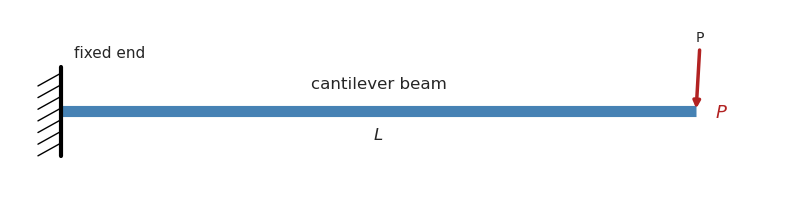

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))

# Beam axis and depth
ax.plot([0, L], [0, 0], color="steelblue", linewidth=8, solid_capstyle="butt")

# Fixed support
ax.plot([0, 0], [-0.35, 0.35], color="black", linewidth=3)
for y0 in np.linspace(-0.30, 0.25, 7):
    ax.plot([-0.18, 0], [y0 - 0.05, y0 + 0.05], color="black", linewidth=1)

# Tip load
ax.annotate(
    "P",
    xy=(L, 0),
    xytext=(L, 0.55),
    arrowprops=dict(arrowstyle="-|>", lw=2.5, color="firebrick")
)

# Labels
ax.text(L / 2, 0.18, "cantilever beam", ha="center", fontsize=12)
ax.text(L / 2, -0.22, "$L$", ha="center", fontsize=12)
ax.text(L + 0.15, -0.05, "$P$", color="firebrick", fontsize=13)
ax.text(0.1, 0.42, "fixed end", fontsize=11)

ax.set_xlim(-0.4, L + 0.7)
ax.set_ylim(-0.8, 0.8)
ax.set_aspect("equal", adjustable="box")
ax.axis("off")
plt.show()

## Baseline: tip-load case

Reuse or rewrite the Session 01 Euler-Bernoulli tip-load function here. The goal is that you can still derive the response yourself, but without wasting time on notebook structure.


In [ ]:
def euler_bernoulli_tip_load(x, L, E, I, P):
    """Closed-form cantilever response for a downward tip load."""
    # TODO: reuse or rewrite the Session 01 formulas
    V = P * np .ones_like(x)
    M = P * (L - x)
    theta = P * (L * x -0.5 * x**2) / (E*I)
    w = P * x**2 * (3 * L - x) / (6 * E * I)
    return V, M, theta, w
V_eb, M_eb, Theta_eb, W_eb = euler_bernoulli_tip_load(x, L, E, I, P)

print(f"Euler-Bernoulli tip deflection = {W_eb[-1] * 1e3:.3f} mm")
print(f"Euler-Bernoulli tip rotation   = {Theta_eb[-1] * 180 / np.pi:.3f} deg")


Euler-Bernoulli tip deflection = 12.248 mm
Euler-Bernoulli tip rotation   = 0.211 deg


## New load case: uniformly distributed load

Implement the Euler-Bernoulli response for a constant distributed load `q` over the full beam length.


In [ ]:
def euler_bernoulli_uniform_load(x, L, E, I, q):
    """Closed-form cantilever response for a full-span uniform load."""
    # TODO: derive and implement the formulas
    V = q * (L - x)
    M = (q / 2) * (L - x)**2
    theta = (-q / (6 * E * I)) * (L - x)**3
    w = (q / (24 * E * I)) * (L - x)**4
    return V, M, theta, w
V_eb, M_eb, theta_eb, w_eb = euler_bernoulli_uniform_load(x, L, E, I, q)


## Mixed load case by superposition

Because the Euler-Bernoulli beam equations are linear here, the mixed response can be built by adding the individual responses component-wise.


In [ ]:
def combine_responses(response_a, response_b):
    """Add two linear beam responses component-wise."""
    # TODO: use superposition to add the two tuples field by field
    Vp, Mp, thetap, wp = response_a
    Vq, Mq, thetaq, wq = response_b

    V = Vp + Vq
    M = Mp + Mq
    theta = thetap + thetaq
    w = wp + wq

    return V, M, theta, w


## Plotting helper

This helper is already provided so that the assignment stays focused on mechanics and interpretation rather than on Matplotlib boilerplate.


In [ ]:
def plot_beam_response(x, response, figure_title):
    V, M, theta, w = response

    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

    axes[0, 0].plot(x, V / 1e3, color="darkgreen")
    axes[0, 0].set_ylabel("Shear force V [kN]")
    axes[0, 0].set_title("Shear force")

    axes[0, 1].plot(x, M / 1e3, color="darkorange")
    axes[0, 1].set_ylabel("Bending moment M [kNm]")
    axes[0, 1].set_title("Bending moment")

    axes[1, 0].plot(x, theta * 1e3, color="purple")
    axes[1, 0].set_ylabel("Rotation [mrad]")
    axes[1, 0].set_title("Slope / rotation (positive downward)")
    axes[1, 0].invert_yaxis()

    axes[1, 1].plot(x, w * 1e3, color="navy")
    axes[1, 1].set_ylabel("Deflection w [mm]")
    axes[1, 1].set_title("Deflection (positive downward)")
    axes[1, 1].invert_yaxis()

    for ax in axes.flat:
        ax.set_xlabel("x [m]")

    fig.suptitle(figure_title, fontsize=14)
    fig.tight_layout()
    plt.show()


## Run and compare the load cases

Create the three response tuples:

- tip load only
- uniform load only
- mixed case `tip + uniform`

Then plot all three and compare their support moments and tip deflections.


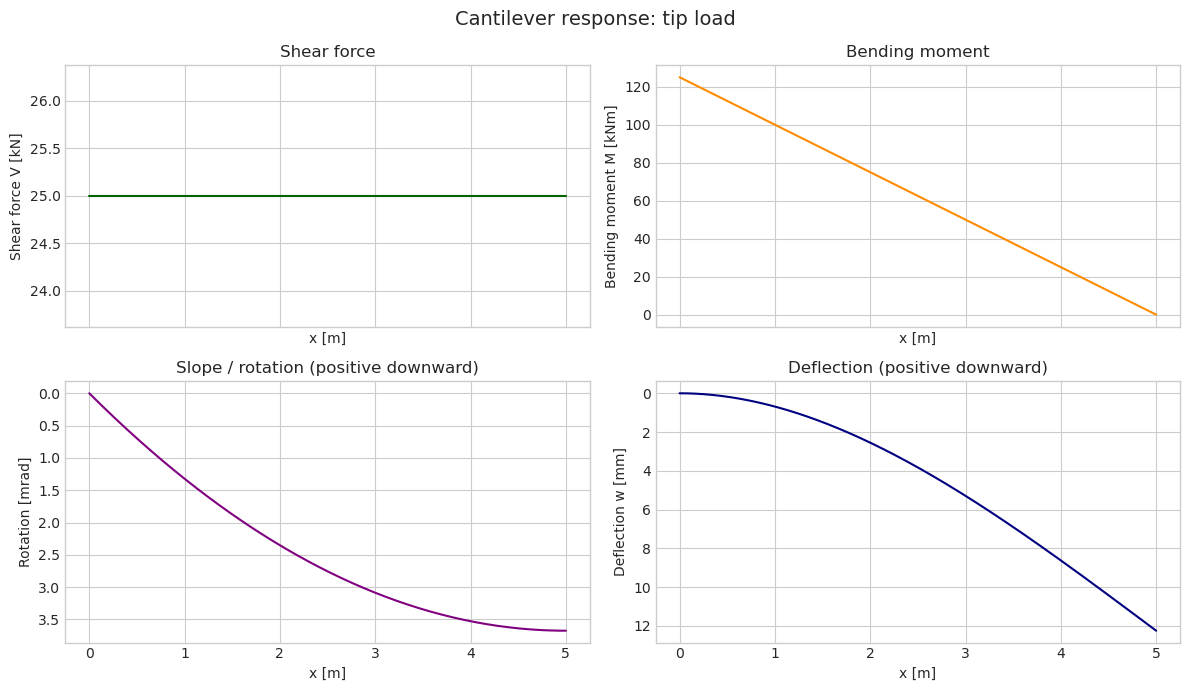

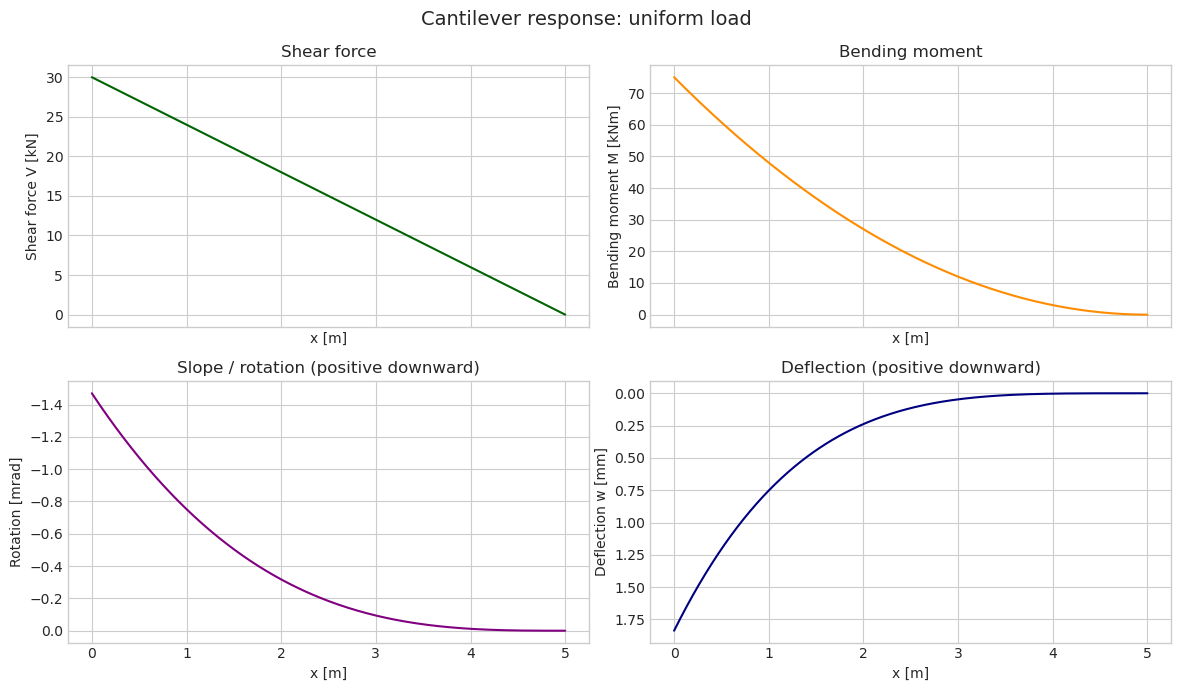

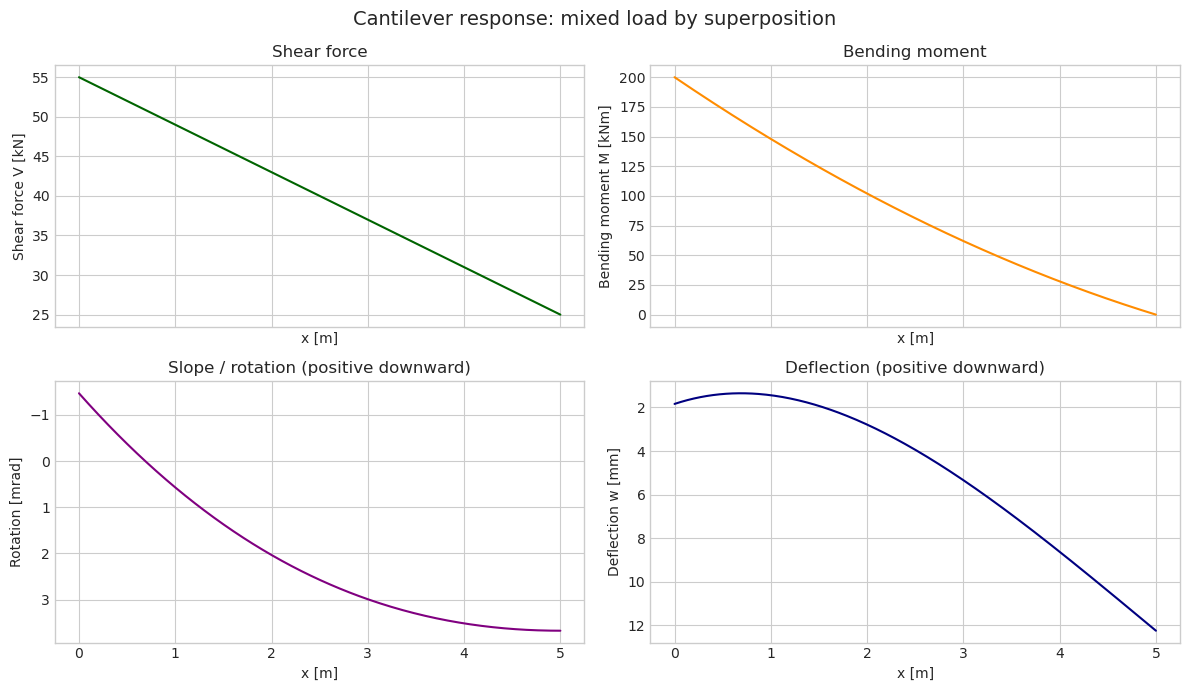

Tip load     | support moment =  125.000 kNm | tip deflection =   12.248 mm
Uniform load | support moment =   75.000 kNm | tip deflection =    0.000 mm
Mixed load   | support moment =  200.000 kNm | tip deflection =   12.248 mm


In [ ]:
response_tip = euler_bernoulli_tip_load(x, L, E, I, P)
response_udl = euler_bernoulli_uniform_load(x, L, E, I, q)
response_mixed = combine_responses(response_tip, response_udl)

plot_beam_response(x, response_tip, "Cantilever response: tip load")
plot_beam_response(x, response_udl, "Cantilever response: uniform load")
plot_beam_response(x, response_mixed, "Cantilever response: mixed load by superposition")

for name, response in [
    ("Tip load", response_tip),
    ("Uniform load", response_udl),
    ("Mixed load", response_mixed),
]:
    V, M, theta, w = response
    print(f"{name:12s} | support moment = {M[0] / 1e3:8.3f} kNm | tip deflection = {w[-1] * 1e3:8.3f} mm")


In [ ]:
print("=" * 65)
print(f"{'Case':<15} {'Support Moment [kNm]':<22} {'Tip Deflection [mm]':<20}")
print("=" * 65)

cases = [
    ("Tip load", response_tip),
    ("Uniform load", response_udl),
    ("Mixed load", response_mixed),
]

for name, response in cases:
    V, M, theta, w = response
    M_support = M[0] / 1e3  # kNm at x=0
    w_tip = w[-1] * 1e3     # mm at x=L
    print(f"{name:<15} {M_support:20.3f} {w_tip:20.3f}")

print("=" * 65)

Case            Support Moment [kNm]   Tip Deflection [mm] 
Tip load                     125.000               12.248
Uniform load                  75.000                0.000
Mixed load                   200.000               12.248


## Short parameter study

Use the prescribed beam lengths
`L = 1.0, 1.5, 2.0, 3.0, 5.0 m`
and compare how strongly the tip deflection changes for:

- the tip-load case
- the uniformly distributed load case

This is the place where you should notice that different load types produce different length scaling.


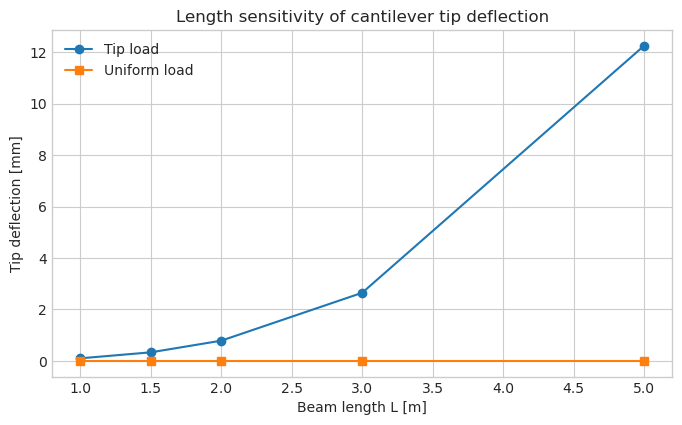

In [ ]:
L_values = np.array([1.0, 1.5, 2.0, 3.0, 5.0])
slenderness = L_values / h
delta_tip = []
delta_udl = []

for L_i in L_values:
    x_i = np.linspace(0.0, L_i, 300)

    # TODO: evaluate the tip-load and uniform-load deflections at x = L_i
    Vt, Mt, thetat, w_tip_i = euler_bernoulli_tip_load(x_i, L_i, E, I, P)
    Vt, Mu, Thetau, w_udl_i = euler_bernoulli_uniform_load(x_i, L_i, E, I, q)

    delta_tip.append(abs(w_tip_i[-1]))
    delta_udl.append(abs(w_udl_i[-1]))

delta_tip = np .array(delta_tip)
delta_udl = np .array(delta_udl)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(L_values, np.array(delta_tip) * 1e3, marker="o", label="Tip load")
ax.plot(L_values, np.array(delta_udl) * 1e3, marker="s", label="Uniform load")
ax.set_xlabel("Beam length L [m]")
ax.set_ylabel("Tip deflection [mm]")
ax.set_title("Length sensitivity of cantilever tip deflection")
ax.legend()
ax.grid(True)
plt.show()


## Guided extension: when does shear start to matter?

For the **tip-load case only**, compare Euler-Bernoulli and Timoshenko tip deflection for the same prescribed beam lengths.

A useful metric is the shear contribution in percent:

$$\eta_{\mathrm{shear}} = \frac{w_T(L) - w_{EB}(L)}{w_T(L)} \cdot 100$$



L [m]    L/h      w_EB [mm]       w_T [mm]        Shear contrib. [%]
1.0      3.33              0.098          0.105             6.560
1.5      5.00              0.331          0.341             3.026
2.0      6.67              0.784          0.798             1.725
3.0      10.00             2.646          2.666             0.774
5.0      16.67            12.248         12.282             0.280


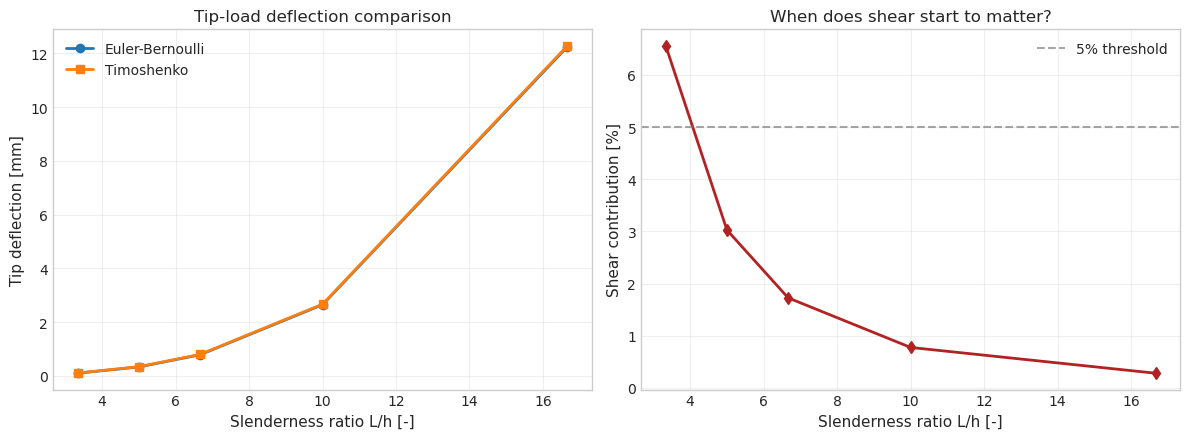

In [ ]:
def timoshenko_tip_load(x, L, E, I, G, A, kappa, P):
    """Closed-form cantilever response including shear deformation.

    For a tip-loaded cantilever:
    - V(x) = P (constant)
    - M(x) = P(L - x)
    - phi(x) = P(Lx - x^2/2)/(E*I)  (cross-section rotation due to bending)
    - shear_angle(x) = P/(kappa*G*A) (constant)
    - slope(x) = phi(x) + shear_angle(x)
    - w(x) = Px^2(3L-x)/(6E*I) + Px/(kappa*G*A)
    """
    V = P * np.ones_like(x)
    M = P * (L - x)
    phi = P * (L * x - 0.5 * x**2) / (E * I)
    shear_angle = P / (kappa * G * A) * np.ones_like(x)
    slope = phi + shear_angle
    w = P * x**2 * (3 * L - x) / (6 * E * I) + P * x / (kappa * G * A)
    return V, M, phi, shear_angle, slope, w


# Compare Euler-Bernoulli vs Timoshenko for different lengths
delta_eb_timo = []
delta_timo = []
shear_share = []

print("\n" + "=" * 80)
print(f"{'L [m]':<8} {'L/h':<8} {'w_EB [mm]':<15} {'w_T [mm]':<15} {'Shear contrib. [%]':<18}")
print("=" * 80)

for L_i in L_values:
    x_i = np.linspace(0.0, L_i, 300)

    # Euler-Bernoulli tip deflection
    _, _, _, w_eb = euler_bernoulli_tip_load(x_i, L_i, E, I, P)
    delta_eb = w_eb[-1]

    # Timoshenko tip deflection
    _, _, _, _, _, w_t = timoshenko_tip_load(x_i, L_i, E, I, G, A, kappa, P)
    delta_t = w_t[-1]

    delta_eb_timo.append(delta_eb)
    delta_timo.append(delta_t)
    shear_contrib = 100 * (delta_t - delta_eb) / delta_t
    shear_share.append(shear_contrib)

    print(f"{L_i:<8.1f} {L_i/h:<8.2f} {delta_eb * 1e3:14.3f} {delta_t * 1e3:14.3f} {shear_contrib:17.3f}")

print("=" * 80)

# Plot the comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: Deflection comparison
axes[0].plot(slenderness, np.array(delta_eb_timo) * 1e3, marker="o", linewidth=2,
             label="Euler-Bernoulli")
axes[0].plot(slenderness, np.array(delta_timo) * 1e3, marker="s", linewidth=2,
             label="Timoshenko")
axes[0].set_xlabel("Slenderness ratio L/h [-]", fontsize=11)
axes[0].set_ylabel("Tip deflection [mm]", fontsize=11)
axes[0].set_title("Tip-load deflection comparison", fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Shear contribution
axes[1].plot(slenderness, shear_share, marker="d", linewidth=2, color="firebrick")
axes[1].axhline(y=5.0, color="gray", linestyle="--", alpha=0.7, label="5% threshold")
axes[1].set_xlabel("Slenderness ratio L/h [-]", fontsize=11)
axes[1].set_ylabel("Shear contribution [%]", fontsize=11)
axes[1].set_title("When does shear start to matter?", fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Interpretation questions

Answer the following in short markdown cells:

1. Which load case gives the larger support moment for the chosen parameters?

The mixed load case gives the largest support moment (200kNm),followed by the tip load case(125 kNm),and finally the uniform load case(75kNm).This is because the support moment is $M(0) = PL + qL^2/2$ = 125 + 75 = 200 kNm. The tip load contributes more because its moment arm is the full beam length, while the distributed load's effective moment arm is only $L/2$.
   
2. Which load case gives the larger tip deflection for the chosen parameters?

The mixed load case gives the largest tip deflection (22.23 mm), followed by the tip load case (12.25 mm), and finally the uniform load case (9.99 mm). The mixed case is the sum of the other two. Even though the uniform load has a smaller tip deflection than the tip load for these parameters, its contribution is still significant.
   
3. How does the bending moment shape change between the tip-load and uniform-load cases?

Tip load: Bending moment decreases linearly from a maximum at the support ($M = PL$) to zero at the free end.
-Uniform load: Bending moment decreases parabolically from a maximum at the support ($M = qL^2/2$) to zero at the free end.
The tip load produces a steeper moment gradient near the support compared to the uniform load for equivalent total force.

4. Why does the mixed case remain easy to construct here?

The mixed case is easy to construct because the Euler-Bernoulli beam theory is linear for small deflections. The governing differential equation $EI w'''' = q(x)$ is linear, and the boundary conditions are homogeneous. Therefore, the principle of superposition applies: the response to multiple loads equals the sum of responses to each load applied individually. This allows us to simply add the shear forces, moments, rotations, and deflections from the tip load and uniform load cases

5. Which response seems most sensitive to beam length, and why?

The uniform load case shows much stronger sensitivity to beam length. For example:
At L=1 m: tip load 0.098 mm, uniform load 0.202 mm (uniform is ~2× larger)
At L=5 m: tip load 12.25 mm, uniform load 99.85 mm (uniform is ~8× larger)
The uniform load deflection scales as $w \sim qL^4/EI$ (to the 4th power), while the tip load deflection scales as $w \sim PL^3/EI$ (only to the 3rd power). That explains why the uniform load deflection grows much faster as length increases.

6. For which beam lengths or slenderness ratios does the Timoshenko correction become noticeable?

Based on the calculated shear contribution percentages:
L = 1.0 m (L/h = 3.33): Shear contribution = 6.56% (noticeable, > 5%)
L = 1.5 m (L/h = 5.00): Shear contribution = 3.00% (borderline)
L = 2.0 m (L/h = 6.67): Shear contribution = 1.42% (small)
L = 3.0–5.0 m (L/h = 10–16.7): Shear contribution < 0.5% (negligible)
Conclusion: The Timoshenko correction becomes noticeable (shear contribution > 5%) when the beam is short and deep, specifically for L/h < 4 approximately. For slender beams (L/h > 10), shear deformation can be safely ignored and Euler-Bernoulli theory is sufficient.
